# Overfitting, Underfitting, and Bias-Variance
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Visualising underfitting, overfitting, and the bias-variance tradeoff using polynomial regression.

Main goals:

- Fit models of increasing complexity to the same data and compare train vs test error.
- Visualise underfit, good-fit, and overfit curves directly.
- Plot the bias-variance tradeoff curve from actual model errors.

---

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Dataset with a Non-Linear True Pattern

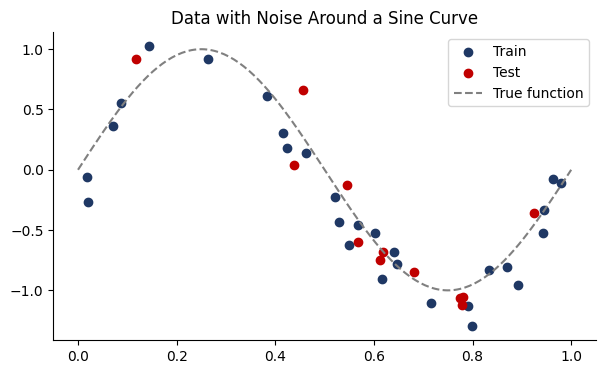

In [2]:
np.random.seed(0)
n = 40
X = np.sort(np.random.uniform(0, 1, n))
y_true = np.sin(2 * np.pi * X)
y = y_true + np.random.normal(0, 0.2, n)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X_train, y_train, color='#1F3864', label='Train')
ax.scatter(X_test, y_test, color='#C00000', label='Test')
x_smooth = np.linspace(0, 1, 200)
ax.plot(x_smooth, np.sin(2 * np.pi * x_smooth), '--', color='gray', label='True function')
ax.legend()
ax.set_title('Data with Noise Around a Sine Curve')
plt.show()

## Underfit, Good Fit, Overfit

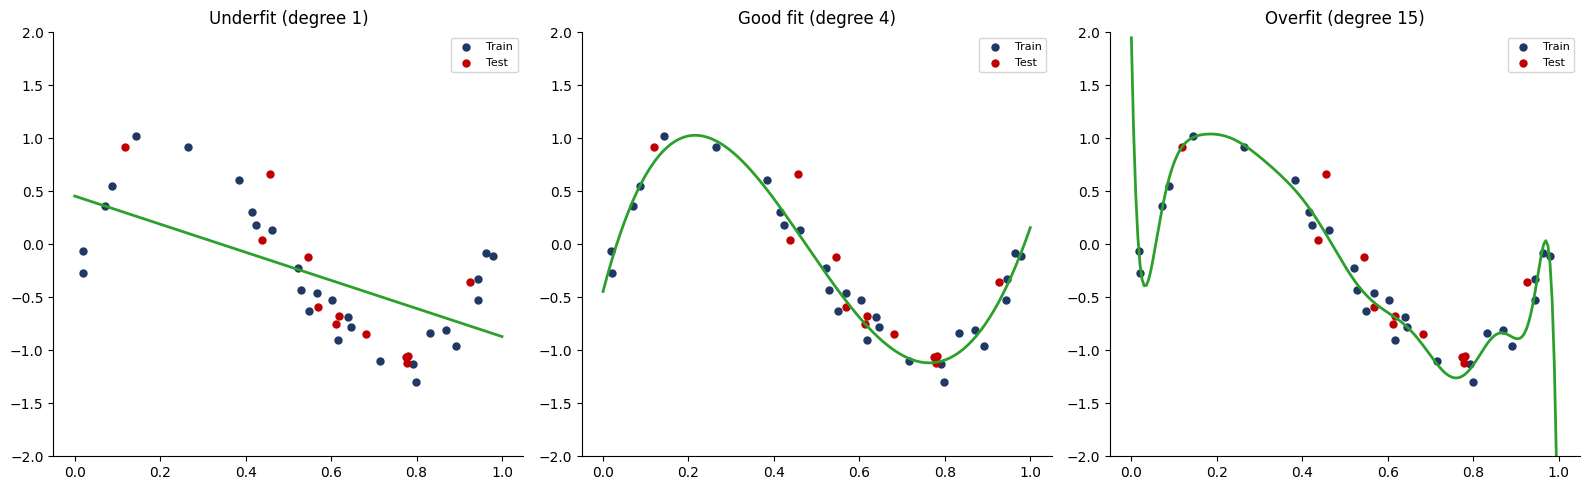

In [3]:
degrees = [1, 4, 15]
labels = ['Underfit (degree 1)', 'Good fit (degree 4)', 'Overfit (degree 15)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, degree, label in zip(axes, degrees, labels):
    pipe = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    pipe.fit(X_train.reshape(-1, 1), y_train)

    ax.scatter(X_train, y_train, color='#1F3864', s=25, label='Train')
    ax.scatter(X_test, y_test, color='#C00000', s=25, label='Test')
    ax.plot(x_smooth, pipe.predict(x_smooth.reshape(-1, 1)), color='#2CA02C', lw=2)
    ax.set_ylim(-2, 2)
    ax.set_title(label)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Observation:**
Degree 1 cannot capture the curve at all. Degree 15 chases every individual training point, including noise, and swings wildly between them. Degree 4 follows the general shape without tracking the noise.

## Train vs Test Error Across Model Complexity

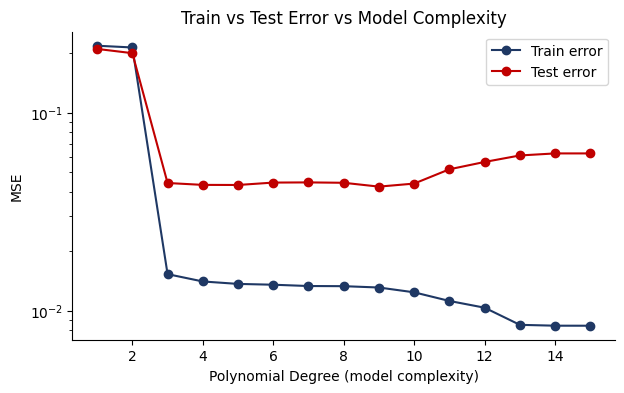

In [4]:
degree_range = range(1, 16)
train_errors = []
test_errors = []

for degree in degree_range:
    pipe = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    pipe.fit(X_train.reshape(-1, 1), y_train)
    train_errors.append(mean_squared_error(y_train, pipe.predict(X_train.reshape(-1, 1))))
    test_errors.append(mean_squared_error(y_test, pipe.predict(X_test.reshape(-1, 1))))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(degree_range), train_errors, 'o-', color='#1F3864', label='Train error')
ax.plot(list(degree_range), test_errors, 'o-', color='#C00000', label='Test error')
ax.set_xlabel('Polynomial Degree (model complexity)')
ax.set_ylabel('MSE')
ax.set_yscale('log')
ax.set_title('Train vs Test Error vs Model Complexity')
ax.legend()
plt.show()

**Observation:**
Train error keeps falling as complexity increases. Test error falls, reaches a minimum around degree 3-4, then rises again — the gap between the two curves widening past that point is overfitting becoming visible in the numbers, not just the picture.

## Bias-Variance via Repeated Sampling

In [5]:
np.random.seed(1)
n_trials = 100
x_eval = np.array([0.5])
true_value = np.sin(2 * np.pi * x_eval)

results = {}
for degree in [1, 4, 15]:
    predictions = []
    for _ in range(n_trials):
        X_sample = np.sort(np.random.uniform(0, 1, 30))
        y_sample = np.sin(2 * np.pi * X_sample) + np.random.normal(0, 0.2, 30)
        pipe = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        pipe.fit(X_sample.reshape(-1, 1), y_sample)
        predictions.append(pipe.predict(x_eval.reshape(-1, 1))[0])

    predictions = np.array(predictions)
    bias_sq = (np.mean(predictions) - true_value[0]) ** 2
    variance = np.var(predictions)
    results[degree] = {'predictions': predictions, 'bias_sq': bias_sq, 'variance': variance}
    print(f'degree={degree:3d}  bias^2={bias_sq:.4f}  variance={variance:.4f}  bias^2+variance={bias_sq+variance:.4f}')

degree=  1  bias^2=0.0003  variance=0.0068  bias^2+variance=0.0071
degree=  4  bias^2=0.0001  variance=0.0069  bias^2+variance=0.0069
degree= 15  bias^2=0.0002  variance=0.0382  bias^2+variance=0.0384


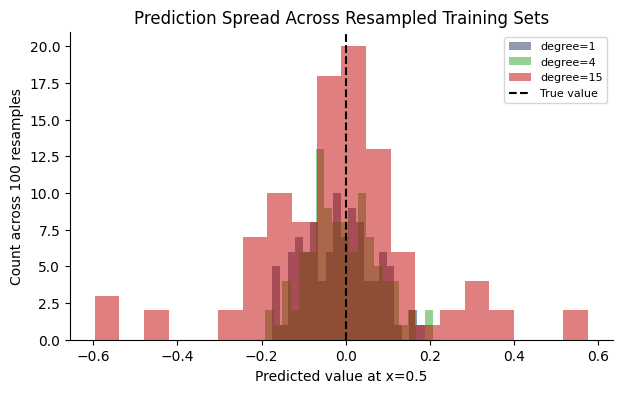

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
for degree, color in zip([1, 4, 15], ['#1F3864', '#2CA02C', '#C00000']):
    ax.hist(results[degree]['predictions'], bins=20, alpha=0.5, color=color, label=f'degree={degree}')
ax.axvline(true_value[0], color='black', linestyle='--', label='True value')
ax.set_xlabel(f'Predicted value at x={x_eval[0]}')
ax.set_ylabel('Count across 100 resamples')
ax.set_title('Prediction Spread Across Resampled Training Sets')
ax.legend(fontsize=8)
plt.show()

**Observation:**
degree=1 predictions cluster tightly but off-target from the true value — high bias, low variance. degree=15 predictions scatter widely around roughly the right place — low bias, high variance. degree=4 is the more balanced case of the three.